# Estimation Errors and Kelly Risk Under Uncertainty

<a href="https://www.kaggle.com/code/addarm/kelly-under-uncertainty" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

![Penalized Regressions](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/kelly_under_uncertainty.png)

This is a small companion article to [The Mathematics of a Retail Trader's Ruin](https://medium.com/hecatus-research/the-mathematics-of-a-retail-traders-ruin-3521d6556b71). From that previous article, suppose a strategy really wins 55% of even-money trades. How much capital should we risk on each trade - a question we touched before.

As you have guessed betting nothing wastes the edge, but, betting everything can lead to one loss wiping out your account. So technically, somewhere between those extremes is a fraction that leads to optimal and repeated compounding: The Kelly criterion.

This was an extension requested by my readers, and hopefull it helps disambiguate Kelly in all its forms.

## Notebook Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Compounding

As we said in the intro, sizing matters because it leads to wealth compounding or not. 

Say we start with 100, gain 50%, then lose 50% (already discussed in the previous article). With 50% returns, we're at 150, but followed by a lose of 50%, we're not back to 100, but at 75! You can say that the two percentage returns average to zero, but wealth ends 25% lower! This happes because returns compound multiplicatively rather than additively. We can Formalized it as:

$$
(1+f)(1-f) = 1-f^2.
$$

Let $W_n$ be wealth after $n$ trades, $f$ the fraction of current wealth risked on each trade, and $R_t$ the outcome of trade $t$: $+1$ for a win and $-1$ for a loss. Assume independent trades with the same $p$ and $0\le f<1$. Then

$$
\begin{aligned}
W_n
&=
W_0\prod_{t=1}^{n}(1+fR_t)\\
\log\left(\frac{W_n}{W_0}\right)
&=
\sum_{t=1}^{n}\log(1+fR_t).
\end{aligned}
$$

As we hinted in the previous article, taking logs turns multiplication into addition, allowing us to measure the average growth contributed by each trade and optimize the long-run rate at which wealth compounds. On an even-money trade, a win multiplies wealth by $1+f$ with probability $p$, while a loss multiplies it by $1-f$ with probability $q=1-p$. The expected log growth per trade is

$$
g(f)=p\log(1+f)+q\log(1-f).
$$

Positive $g(f)$ means positive expected log growth; negative $g(f)$ means negative expected log growth. We now need the value of $f$ that maximizes $g(f)$.

## Kelly at Known Probability

Differentiate $g(f)$, set the derivative to zero, and solve:

$$
\begin{aligned}
g(f) &= p\log(1+f)+q\log(1-f)\\
g'(f) &= \frac{p}{1+f}-\frac{q}{1-f}\\
0 &= \frac{p}{1+f}-\frac{q}{1-f}\\
p(1-f) &= q(1+f)\\
p-pf &= q+qf\\
p-q &= f(p+q)\\
f^* &= p-q\\
&=2p-1.
\end{aligned}
$$

Remember that $p+q=1$ as both outcomes are 100% together, so the parenthesis for $f$ resolved to 1 and could be dropped. The derivative tells us where growth plateaus as $g$ is concave because $g''(f)=-p/(1+f)^2-q/(1-f)^2<0$, so this point is the maximum.

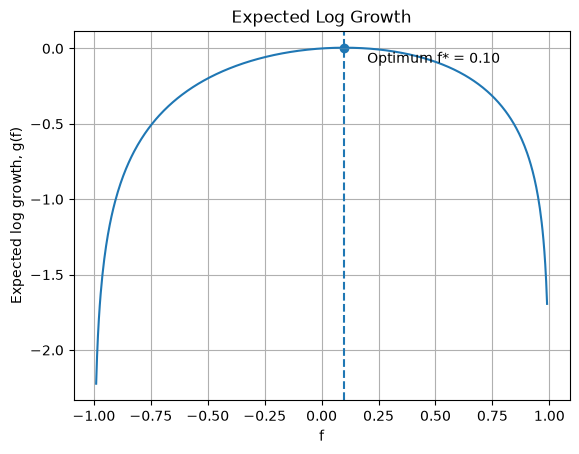

In [2]:
p = 0.55
q = 1 - p

f = np.linspace(-0.99, 0.99, 500)
g = p * np.log(1 + f) + q * np.log(1 - f)

f_star = 2 * p - 1
g_star = p * np.log(1 + f_star) + q * np.log(1 - f_star)

plt.plot(f, g)
plt.scatter(f_star, g_star)
plt.axvline(f_star, linestyle="--")

plt.annotate(f"Optimum f* = {f_star:.2f}", (f_star, g_star), xytext=(f_star + 0.1, g_star - 0.1))

plt.title("Expected Log Growth")
plt.xlabel("f")
plt.ylabel("Expected log growth, g(f)")
plt.grid()
plt.show()


For the strategy in our opening question,

$$
\begin{aligned}
p &= 0.55\\
f^*
&=2p-1\\
&=2(0.55)-1\\
&=0.10.
\end{aligned}
$$

If the true win probability really is 55%, full Kelly says to risk 10% of current wealth on each trade. 
Keep in mind that the formula $f^*=2p-1$ applies to this even-money binary setup - it is not the universal Kelly formula!

## Overbetting 

For the true $p=0.55$,

$$
g(f)=0.55\log(1+f)+0.45\log(1-f).
$$

Betting too little leaves some growth unused. Betting 10% maximizes expected log growth. Betting more than Kelly reduces it.

At approximately 19.9%, expected log growth has fallen all the way back to zero. Beyond that boundary, the trade still has positive arithmetic expectancy because $p-q=0.10$, but its expected log growth is negative. This is the danger of overbetting even before estimation error enters the story.

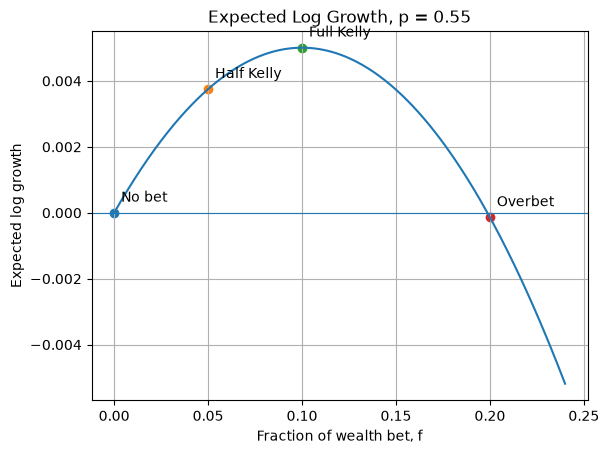

In [3]:
def growth(f):
    return p * np.log(1 + f) + (1 - p) * np.log(1 - f)


f = np.linspace(0, 0.24, 400)
g = growth(f)
true_p = 0.55
kelly = 2 * p - 1

plt.plot(f, g)
plt.axhline(0, linewidth=0.8)

points = [
    (0.00, "No bet"),
    (0.05, "Half Kelly"),
    (0.10, "Full Kelly"),
    (0.20, "Overbet"),
]

for x, label in points:
    y = growth(x)
    plt.scatter(x, y)
    plt.annotate(label, (x, y), xytext=(5, 8), textcoords="offset points")

plt.title("Expected Log Growth, p = 0.55")
plt.xlabel("Fraction of wealth bet, f")
plt.ylabel("Expected log growth")
plt.grid()
plt.show()


## Estimating the Probability

Now, all of this is fine - if we knew $p$ - but in real life trading or uncertain environments like sports, we don't know the real $p$ (and if you remember from the previous article, even if we do, it changes). Suppose we observe:

$$
\begin{aligned}
n &= 100\\
K &= 55\\
\hat p &= \frac{K}{n}=0.55.
\end{aligned}
$$

Fifty-five wins from 100 trades do not establish that the underlying probability is exactly 55%. Using a Wilson confidence interval to ask how precisely 100 trades identify $p$ with $z\approx1.96$ for a 95% confidence interval, we calculate:

$$
\begin{aligned}
c
&=\frac{\hat p+\dfrac{z^2}{2n}}{1+\dfrac{z^2}{n}}
\approx0.548\\
h
&=\frac{z}{1+\dfrac{z^2}{n}}
\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}
\approx0.096\\
[Lower,Upper]
&=[c-h,c+h]\\
&\approx[0.452,0.644].
\end{aligned}
$$

For this sample, the 95% Wilson confidence interval is approximately $[0.452,0.644]$. The point estimate is 55%, but 100 trades still leave substantial uncertainty about the underlying win probability. $p$ is not merely something we report. Kelly uses it to determine how much capital we risk.

In [4]:
def wilson_interval(successes, trials, z=1.959963984540054):
    estimate = successes / trials
    denominator = 1 + z**2 / trials
    center = (estimate + z**2 / (2 * trials)) / denominator
    half_width = z / denominator * np.sqrt(estimate * (1 - estimate) / trials + z**2 / (4 * trials**2))
    return center - half_width, center + half_width


wilson_lower, wilson_upper = wilson_interval(55, 100)
print(f"Wilson 95% interval for 55/100: [{wilson_lower:.3f}, {wilson_upper:.3f}]")

Wilson 95% interval for 55/100: [0.452, 0.644]


In [5]:
n_trades = 100
true_p = 0.55
zero_growth = 0.199
wins_dist = stats.binom(n_trades, true_p)
p_no_trade = wins_dist.cdf(50)
p_overbet = wins_dist.sf(59)


def kelly_fraction(p_hat):
    return np.maximum(0, 2 * p_hat - 1)


def expected_log_growth(f, p=0.55):
    return p * np.log1p(f) + (1 - p) * np.log1p(-f)


print(f"P(p_hat <= 0.50) = P(K <= 50) = {p_no_trade:.4f}")
print(f"P(p_hat >= 0.60) = P(K >= 60) = {p_overbet:.4f}")
print(f"Kelly size at p_hat = 0.60: {kelly_fraction(0.60):.2f}, zero-growth boundary: {zero_growth:.3f}")


P(p_hat <= 0.50) = P(K <= 50) = 0.1827
P(p_hat >= 0.60) = P(K >= 60) = 0.1831
Kelly size at p_hat = 0.60: 0.20, zero-growth boundary: 0.199


## From Probability Error to Sizing Error

Plug-in Kelly treats the estimated win probability as if it were the true one:

$$
\begin{aligned}
\hat f &= \max(0,2\hat p-1)\\[4pt]
\hat p=0.50 &\Rightarrow \hat f=0\%\\
\hat p=0.55 &\Rightarrow \hat f=10\%\\
\hat p=0.60 &\Rightarrow \hat f=20\%.
\end{aligned}
$$

Kelly sizes the **edge**, not the win probability itself. Moving from 55% to 60% looks like a small five-percentage-point error, but the estimated edge over a 50/50 game has doubled from 5% to 10%. The Kelly position therefore doubles from 10% to 20%.

Now suppose the true probability is still $p=0.55$, but we estimate it from only 100 independent trades. If $K$ is the number of wins,


$$
\begin{aligned}
K\sim\operatorname{Binomial}(100,0.55)\\
\hat p=\frac{K}{100}.
\end{aligned}
$$

To estimate $\hat p\ge0.60$, we need at least 60 wins as $\hat p\ge0.60$ if $K\ge60$. So the probability that sampling noise makes Kelly recommend at least a 20% position is

$$
\begin{aligned}
P(\hat f\ge0.20)
&=P(\hat p\ge0.60)\\
&=P(K\ge60)\\
&=\sum_{k=60}^{100}
\binom{100}{k}
(0.55)^k(0.45)^{100-k}\\
&\approx18.3\%.
\end{aligned}
$$

So even though the true Kelly bet is only 10%, there is about an **18% chance** that a 100-trade sample tells us to bet 20% or more. This matters because, with the true $p=0.55$, our growth curve crosses zero at about $f_{\text{zero growth}}\approx19.9\%$.

So a fairly ordinary sampling error can move us from the growth-optimal 10% bet to roughly the point where expected log growth disappears. A small error in $\hat p$ can therefore become a very large error in position size.

## Fractional Kelly

Fractional Kelly scales the full-Kelly position by a fixed factor $\lambda$. Half Kelly uses $\lambda=0.5$:

$$
\begin{aligned}
f_\lambda
&=\lambda f_{\text{Kelly}},
\qquad 0<\lambda<1\\
f_{\text{half}}
&=0.5f_{\text{Kelly}}.
\end{aligned}
$$

Return to the same estimation error:

$$
\begin{aligned}
\hat p &= 0.60\\
f_{\text{full}} &=20\%\\
f_{\text{half}} &=10\%.
\end{aligned}
$$

With full Kelly, this error pushes the position from the true optimum of 10% to roughly the true zero-growth boundary at 19.9%.

Half Kelly cuts the sizing error in half. The same estimate of $\hat p=0.60$ now gives a 10% position, which happens to equal the true Kelly optimum in this example. That is a coincidence caused by these particular numbers.

For half Kelly to reach the same 19.9% zero-growth boundary, the estimated win probability would have to be much higher:

$$
\begin{aligned}
f_{\text{half}} &= \frac12(2\hat p-1)\\
\frac12(2\hat p-1) &\approx0.199\\
2\hat p-1 &\approx0.398\\
\hat p &\approx0.699\approx70\%.
\end{aligned}
$$

So full Kelly reaches this dangerous position size when the estimate rises from 55% to about 60%. Half Kelly does not reach it until the estimate rises to about 70%.

With 100 independent trades,

$$
K\sim\operatorname{Binomial}(100,0.55),
$$

so reaching an estimated win rate of at least 70% means observing at least 70 wins:

$$
\begin{aligned}
P(K\ge70)
&=\sum_{k=70}^{100}
\binom{100}{k}(0.55)^k(0.45)^{100-k}\\
&\approx0.00154\\
&\approx0.15\%.
\end{aligned}
$$

Compare that with the roughly 18.3% probability that full Kelly reaches the same dangerous region.

More data reduce the uncertainty in $\hat p$. Fractional Kelly attacks the problem from the other side: it reduces how strongly an error in $\hat p$ changes the position size.

Half Kelly is not universally optimal. The appropriate fraction depends on how uncertain we are about the estimated edge.

## Run Simulations to Validate

The analytical argument is primary. A simulation provides a compact check. We draw 10,000 samples of 100 trades from the true $p=0.55$, estimate $p$ from each sample, and compare the true expected log growth of the resulting full- and half-Kelly positions.

In [6]:
sim_rng = np.random.default_rng(42)
n_histories = 10_000

sim_wins = sim_rng.binomial(n_trades, true_p, size=n_histories)
sim_p = sim_wins / n_trades

sim_full = kelly_fraction(sim_p)
sim_half = 0.5 * sim_full

simulation_check = pd.DataFrame(
    {
        "quantity": [
            "P(K >= 60)",
            "P(K <= 50)",
            "P(growth < 0), full Kelly",
            "P(growth < 0), half Kelly",
        ],
        "simulated": [
            (sim_wins >= 60).mean(),
            (sim_wins <= 50).mean(),
            (sim_full > zero_growth).mean(),
            (sim_half > zero_growth).mean(),
        ],
        "exact": [
            p_overbet,
            p_no_trade,
            wins_dist.sf(59),
            wins_dist.sf(69),
        ],
    }
)

print(simulation_check.to_string(index=False, float_format="{:,.6f}".format))

                 quantity  simulated    exact
               P(K >= 60)   0.184800 0.183057
               P(K <= 50)   0.178700 0.182728
P(growth < 0), full Kelly   0.184800 0.183057
P(growth < 0), half Kelly   0.001400 0.001536


The simulation closely matches the exact calculation. With 100 trades, estimated full Kelly produces a position with negative expected log growth about 18.3% of the time. Half Kelly reduces this to about 0.15%.

These numbers depend on the assumed true win rate and sample size, but they show the main point clearly: fractional Kelly makes position sizing much less sensitive to estimation error.

# Conclusion

Full Kelly is optimal for the edge you specify. The problem is that the edge you specify may not be the edge you have.

When $p$ is known under the model assumptions, Kelly maximizes expected log growth. In trading, however, the edge must be estimated. Estimation error therefore becomes sizing error, and because Kelly sizes the edge, a modest error in $p$ can become a much larger relative error in $f$.

Fractional Kelly sacrifices some optimal growth when the estimate is correct to reduce the damage when it is not.

For a broader treatment of expectancy, compounding, ruin, Markov chains, and strategy selection, see [The Mathematics of a Retail Trader's Ruin](https://www.kaggle.com/code/addarm/retail_trader_ruin).

## References

1. Kelly, J. L., Jr. (1956). *A New Interpretation of Information Rate*. https://doi.org/10.1002/j.1538-7305.1956.tb03809.x
2. Thorp, E. O. (2006). *The Kelly Criterion in Blackjack, Sports Betting, and the Stock Market*. https://doi.org/10.1016/S1872-0978(06)01009-X
3. MacLean, L. C., Thorp, E. O., and Ziemba, W. T. (2010). *Long-Term Capital Growth: The Good and Bad Properties of the Kelly and Fractional Kelly Capital Growth Criteria*. https://doi.org/10.1080/14697688.2010.506108

# GitHub

This article is also available on [GitHub](https://github.com/adamd1985/quant_research/blob/main/kelly_under_uncertainty.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/kelly-under-uncertainty)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

# CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.